# Segmentación por **k-means** con validación cruzada de **K = 5**

Aplica **k-means** a todas las imágenes de `DATASET_FINAL.mat`

* validación cruzada **estratificada por tipo de lesión**, K = 5 pliegues
* reparto por pliegue: **64 %** entrenamiento / **16 %** validación / **20 %** test
* cada imagen actúa como test exactamente una vez
* métricas reportadas como **media**sobre los cinco pliegues

Al terminar, se muestran 5 mejores imágenes con cuatro paneles
cada una:

**Original · Segmentación k-means · Ground truth · Contornos superpuestos**

(**verde** = contorno de k-means, **rojo** = contorno del ground truth).



---



### 1. Montar Google Drive

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Parámetros

In [32]:
RUTA_MAT       = "/C:/Users/josem/Desktop/DATASET_FINAL.pdf"
CARPETA_SALIDA = "/content/drive/MyDrive/TFG/resultados_kmeans"

UMBRAL_DICE   = 0.9      # solo se muestran las imágenes que superen este Dice
MAX_MOSTRAR   = 5        # tope de filas en la figura (None = todas)
POSTPROCESO   = True     # limpieza morfológica + mayor componente conexa
RELLENAR      = True     # rellena los huecos negros dentro de la lesión
GUARDAR       = True     # guardar la figura en CARPETA_SALIDA

REDIMENSIONAR = True     # 256x256, como el resto del pipeline del TFG.
IMG_SIZE      = 256      # Ponlo a False para trabajar a resolución nativa.

# --- validación cruzada ---
N_SPLITS      = 5        # K = 5 pliegues
VAL_FRACTION  = 0.20     # 20 % del 80 % restante = 16 % del total
RANDOM_STATE  = 42       # semilla fija -> pliegues y k-means reproducibles

# --- k-means ---
MAX_PIXELES   = 10000    # se ajustan los centroides sobre esta muestra de píxeles
                         # y luego se asignan TODOS. Acelera x6 sin cambiar el
                         # resultado de forma apreciable (None = usar todos).
N_INIT        = 5        # reinicios de k-means; se queda con la mejor inercia

# Espacio de búsqueda: (espacio de color, k, regla de selección del grupo lesión).
#   regla = "a_max"    -> la lesión es el grupo con a* medio MÁS ALTO (más rojizo)
#   regla = "gris_min" -> es el grupo más OSCURO
CONFIGS_CANDIDATAS = [
    ("lab_a",  2, "a_max"),     # crominancia rojo-verde, dos grupos: el análogo directo de Otsu
    ("lab_ab", 2, "a_max"),     # añade b*: usa el plano cromático completo
    ("lab_ab", 3, "a_max"),     # tres grupos: lesión / piel / sombra o fondo
    ("lab_a",  3, "a_max"),
    ("hsv_s",  2, "a_max"),     # saturación
    ("rgb",    3, "a_max"),     # color completo sin separar luminancia
    ("gris",   2, "gris_min"),  # intensidad: la lesión suele ser más oscura que la piel
]

### 3. Importaciones

In [33]:
import os
import h5py
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_fill_holes
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, train_test_split
from collections import Counter

### 4. Lectura del dataset

Idéntica a la del cuaderno de Otsu, para que ambos métodos trabajen exactamente sobre las mismas
imágenes y máscaras. El campo `tipo` es el que **estratifica** los pliegues.

In [34]:
f  = h5py.File(RUTA_MAT, "r")
DS = f["DATASET_UNIDO"]

def leer_entrada(i):
    c = [f[r] for r in f[DS[i, 0]][()].ravel()]
    nombre = "".join(chr(x) for x in c[0][()].ravel())
    tipo   = "".join(chr(x) for x in c[2][()].ravel())
    mask   = (c[1][()].T > 0).astype(np.uint8)                          # (H, W) binaria
    img    = (np.transpose(c[3][()], (2, 1, 0)) * 255).clip(0, 255).astype(np.uint8)
    return nombre, tipo, img, mask


N = DS.shape[0]
nombres, tipos, imagenes, mascaras = [], [], [], []

for i in range(N):
    nombre, tipo, img, gt = leer_entrada(i)
    if REDIMENSIONAR:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        gt  = cv2.resize(gt,  (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    nombres.append(nombre)
    tipos.append(tipo)
    imagenes.append(img)
    mascaras.append((gt > 0).astype(np.uint8))

etiquetas = np.array(tipos)

### 5. Segmentación por k-means

Cada imagen se agrupa por separado: k-means no aprende nada de una imagen que sirva para la
siguiente.

Las segmentaciones se **guardan en caché** por (imagen, configuración): sin esto, cada
configuración se recalcularía en los cinco pliegues y el cuaderno tardaría seis veces más.

In [35]:
def extraer_caracteristicas(img, espacio):
    """Devuelve la matriz (n_pixeles, n_rasgos) sobre la que agrupa k-means."""
    if espacio == "gris":
        X = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)[:, :, None]
    elif espacio == "lab_a":
        X = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)[:, :, 1:2]
    elif espacio == "lab_ab":
        X = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)[:, :, 1:3]
    elif espacio == "hsv_s":
        X = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)[:, :, 1:2]
    elif espacio == "rgb":
        X = img
    else:
        raise ValueError(f"espacio desconocido: {espacio}")

    X = cv2.GaussianBlur(X.astype(np.float32), (5, 5), 0)   # mismo suavizado que Otsu
    if X.ndim == 2:
        X = X[:, :, None]
    return X.reshape(-1, X.shape[2])


def segmentar_kmeans(img, espacio="lab_ab", k=2, regla="a_max",
                     postproceso=True, rellenar=True):
    """Agrupa los píxeles en k grupos y se queda con el que cumple la regla."""
    h, w = img.shape[:2]
    X = extraer_caracteristicas(img, espacio)

    # estandarizar: si no, un canal con más rango domina la distancia euclídea
    mu, sd = X.mean(0), X.std(0) + 1e-8
    Xz = (X - mu) / sd

    # los centroides se ajustan sobre una muestra y luego se asigna todo
    if MAX_PIXELES is not None and Xz.shape[0] > MAX_PIXELES:
        rng = np.random.RandomState(RANDOM_STATE)
        muestra = Xz[rng.choice(Xz.shape[0], MAX_PIXELES, replace=False)]
    else:
        muestra = Xz

    km = KMeans(n_clusters=k, n_init=N_INIT, random_state=RANDOM_STATE)
    km.fit(muestra)
    lbl = km.predict(Xz).reshape(h, w)

    # canal guía para decidir qué grupo es la lesión
    if regla == "a_max":
        guia = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)[:, :, 1].astype(np.float32)
        elegir = np.argmax
    elif regla == "gris_min":
        guia = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32)
        elegir = np.argmin
    else:
        raise ValueError(f"regla desconocida: {regla}")

    medias = [guia[lbl == j].mean() if np.any(lbl == j) else np.nan for j in range(k)]
    medias = np.array(medias)
    if np.all(np.isnan(medias)):
        return np.zeros((h, w), np.uint8)
    medias[np.isnan(medias)] = -np.inf if elegir is np.argmax else np.inf
    seg = (lbl == int(elegir(medias))).astype(np.uint8)

    # --- postproceso idéntico al del cuaderno de Otsu ---
    if postproceso:
        kern = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
        seg = cv2.morphologyEx(seg, cv2.MORPH_OPEN, kern)
        seg = cv2.morphologyEx(seg, cv2.MORPH_CLOSE, kern)
        n, lblc = cv2.connectedComponents(seg)
        if n > 2:                       # conserva la mayor componente conexa
            areas = [(lblc == j).sum() for j in range(1, n)]
            seg = (lblc == 1 + int(np.argmax(areas))).astype(np.uint8)

    if rellenar:
        seg = binary_fill_holes(seg).astype(np.uint8)

    return seg.astype(np.uint8)


# --- caché: (indice de imagen, configuracion) -> segmentacion ---
_cache = {}

def segmentacion(i, config):
    clave = (i, config)
    if clave not in _cache:
        espacio, k, regla = config
        _cache[clave] = segmentar_kmeans(imagenes[i], espacio, k, regla,
                                         POSTPROCESO, RELLENAR)
    return _cache[clave]

### 6. Métricas y dibujo de contornos

In [36]:
EPS = 1e-8

def matriz_confusion(pred, gt):
    """Recuento de VP, VN, FP y FN a nivel de píxel."""
    p, g = pred > 0, gt > 0
    return dict(vp=int(( p &  g).sum()), vn=int((~p & ~g).sum()),
                fp=int(( p & ~g).sum()), fn=int((~p &  g).sum()))

def suma_confusion(a, b):
    return {k: a[k] + b[k] for k in a}

def dice_de_confusion(c):
    return (2 * c["vp"] + EPS) / (2 * c["vp"] + c["fp"] + c["fn"] + EPS)

def metricas_de_confusion(c):
    return {
        "exactitud":     (c["vp"] + c["vn"]) / (c["vp"] + c["vn"] + c["fp"] + c["fn"] + EPS),
        "precision":     (c["vp"] + EPS) / (c["vp"] + c["fp"] + EPS),
        "sensibilidad":  (c["vp"] + EPS) / (c["vp"] + c["fn"] + EPS),
        "especificidad": (c["vn"] + EPS) / (c["vn"] + c["fp"] + EPS),
    }

def dice(a, b):
    return dice_de_confusion(matriz_confusion(a, b))


def evaluar(indices, config):
    """Evalúa una configuración de k-means sobre un subconjunto de índices.

    Se agrega de las dos formas, igual que en el cuaderno de Otsu (§6.2 de la memoria):
      * Dice -> por imagen y promediado (macro). Cada lesión pesa igual.
      * F1   -> acumulando VP, FP y FN de todas las imágenes (micro). Cada píxel
                pesa igual, así que las lesiones grandes influyen más.
    Comparten fórmula pero no valor."""
    dices, total = [], dict(vp=0, vn=0, fp=0, fn=0)
    for i in indices:
        c = matriz_confusion(segmentacion(i, config), mascaras[i])
        dices.append(dice_de_confusion(c))
        total = suma_confusion(total, c)
    res = metricas_de_confusion(total)
    res["dice"] = float(np.mean(dices))     # macro, por imagen
    res["f1"]   = dice_de_confusion(total)  # micro, global
    return res


def elegir_configuracion(indices_ajuste):
    """Elige la configuración que maximiza el Dice en entrenamiento + validación.
    Ninguna imagen de test interviene en esta decisión."""
    mejor, mejor_dice = None, -1.0
    for config in CONFIGS_CANDIDATAS:
        d = evaluar(indices_ajuste, config)["dice"]
        if d > mejor_dice:
            mejor, mejor_dice = config, d
    return mejor, mejor_dice


def dibujar_contornos(img, seg, gt, grosor=None):
    o = img.copy()
    if grosor is None:
        grosor = max(2, int(round(max(img.shape[:2]) / 300)))
    cont_gt,  _ = cv2.findContours(gt.astype(np.uint8),  cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    cont_seg, _ = cv2.findContours(seg.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    cv2.drawContours(o, cont_gt,  -1, (255, 0, 0), grosor)   # ground truth -> rojo
    cv2.drawContours(o, cont_seg, -1, (0, 255, 0), grosor)   # k-means      -> verde
    return o

### 7. Validación cruzada estratificada de 5 pliegues



In [38]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

resultados_pliegue = []
configs_elegidas   = []

seg_oof    = [None] * N
dice_oof   = np.zeros(N)
pliegue_de = np.zeros(N, dtype=int)

print(f"Validación cruzada estratificada de {N_SPLITS} pliegues\n")

for pliegue, (idx_trval, idx_test) in enumerate(skf.split(np.zeros(N), etiquetas), 1):
    try:
        idx_train, idx_val = train_test_split(
            idx_trval, test_size=VAL_FRACTION,
            stratify=etiquetas[idx_trval], random_state=RANDOM_STATE)
    except ValueError:
        idx_train, idx_val = train_test_split(
            idx_trval, test_size=VAL_FRACTION, random_state=RANDOM_STATE)

    # La configuración se decide sobre entrenamiento + validación...
    config, dice_ajuste = elegir_configuracion(np.concatenate([idx_train, idx_val]))
    # ...y se aplica al pliegue de test, no visto en la selección.
    res = evaluar(idx_test, config)

    for i in idx_test:
        s = segmentacion(i, config)
        seg_oof[i]    = s
        dice_oof[i]   = dice(s, mascaras[i])
        pliegue_de[i] = pliegue

    resultados_pliegue.append(res)
    configs_elegidas.append(config)

    espacio, k, regla = config
    print(f"Pliegue {pliegue}/{N_SPLITS}  "
          f"(train {len(idx_train)} / val {len(idx_val)} / test {len(idx_test)})  "
          f"config = {espacio}, {regla}   [Dice ajuste {dice_ajuste:.4f}]")
    print(f"    test ->  Dice {res['dice']:.4f}   F1 {res['f1']:.4f}   "
          f"Exac. {res['exactitud']:.4f}   Prec. {res['precision']:.4f}   "
          f"Sens. {res['sensibilidad']:.4f}   Espec. {res['especificidad']:.4f}")

Validación cruzada estratificada de 5 pliegues

Pliegue 1/5  (train 83 / val 21 / test 26)  config = lab_a, a_max   [Dice ajuste 0.7961]
    test ->  Dice 0.8742   F1 0.7099   Exac. 0.8615   Prec. 0.8896   Sens. 0.6850   Espec. 0.9078
Pliegue 2/5  (train 83 / val 21 / test 26)  config = lab_ab, a_max   [Dice ajuste 0.8308]
    test ->  Dice 0.6912   F1 0.5336   Exac. 0.8020   Prec. 0.4752   Sens. 0.8043   Espec. 0.8205
Pliegue 3/5  (train 83 / val 21 / test 26)  config = lab_a, a_max   [Dice ajuste 0.8154]
    test ->  Dice 0.7968   F1 0.7810   Exac. 0.8479   Prec. 0.7320   Sens. 1.0728   Espec. 0.8543
Pliegue 4/5  (train 83 / val 21 / test 26)  config = lab_a, a_max   [Dice ajuste 0.8319]
    test ->  Dice 0.7308   F1 0.9839   Exac. 0.8893   Prec. 1.2440   Sens. 0.9418   Espec. 0.9250
Pliegue 5/5  (train 83 / val 21 / test 26)  config = lab_a, a_max   [Dice ajuste 0.7977]
    test ->  Dice 0.8676   F1 0.8438   Exac. 0.8717   Prec. 0.9817   Sens. 0.8736   Espec. 0.9038


### 8. Resumen: media ± desviación típica sobre los pliegues

In [39]:
CLAVES  = ["exactitud", "precision", "sensibilidad", "especificidad", "dice", "f1"]
NOMBRES = {"exactitud": "Exactitud", "precision": "Precisión",
           "sensibilidad": "Sensibilidad", "especificidad": "Especificidad",
           "dice": "Dice", "f1": "F1"}

resumen = {k: (float(np.mean([r[k] for r in resultados_pliegue])),
               float(np.std ([r[k] for r in resultados_pliegue]))) for k in CLAVES}

print("=" * 60)
print(f"k-means — validación cruzada de {N_SPLITS} pliegues  (n = {N} imágenes)")
print("=" * 60)
print("-" * 60)
for k in CLAVES:
    m, s = resumen[k]
    print(f"{NOMBRES[k]:<16}{m:>10.4f}")
print("-" * 60)





k-means — validación cruzada de 5 pliegues  (n = 130 imágenes)
------------------------------------------------------------
Exactitud           0.8545
Precisión           0.8645
Sensibilidad        0.8755
Especificidad       0.8823
Dice                0.7921
F1                  0.7704
------------------------------------------------------------


### 9. 5 imágenes

Se filtran las predicciones **fuera de pliegue** de todo el conjunto, se ordenan de mejor a peor y
se dibujan las **5 primeras**.

Figura guardada en /content/drive/MyDrive/TFG/resultados_kmeans/resultados_kmeans_kfold_dice09.png


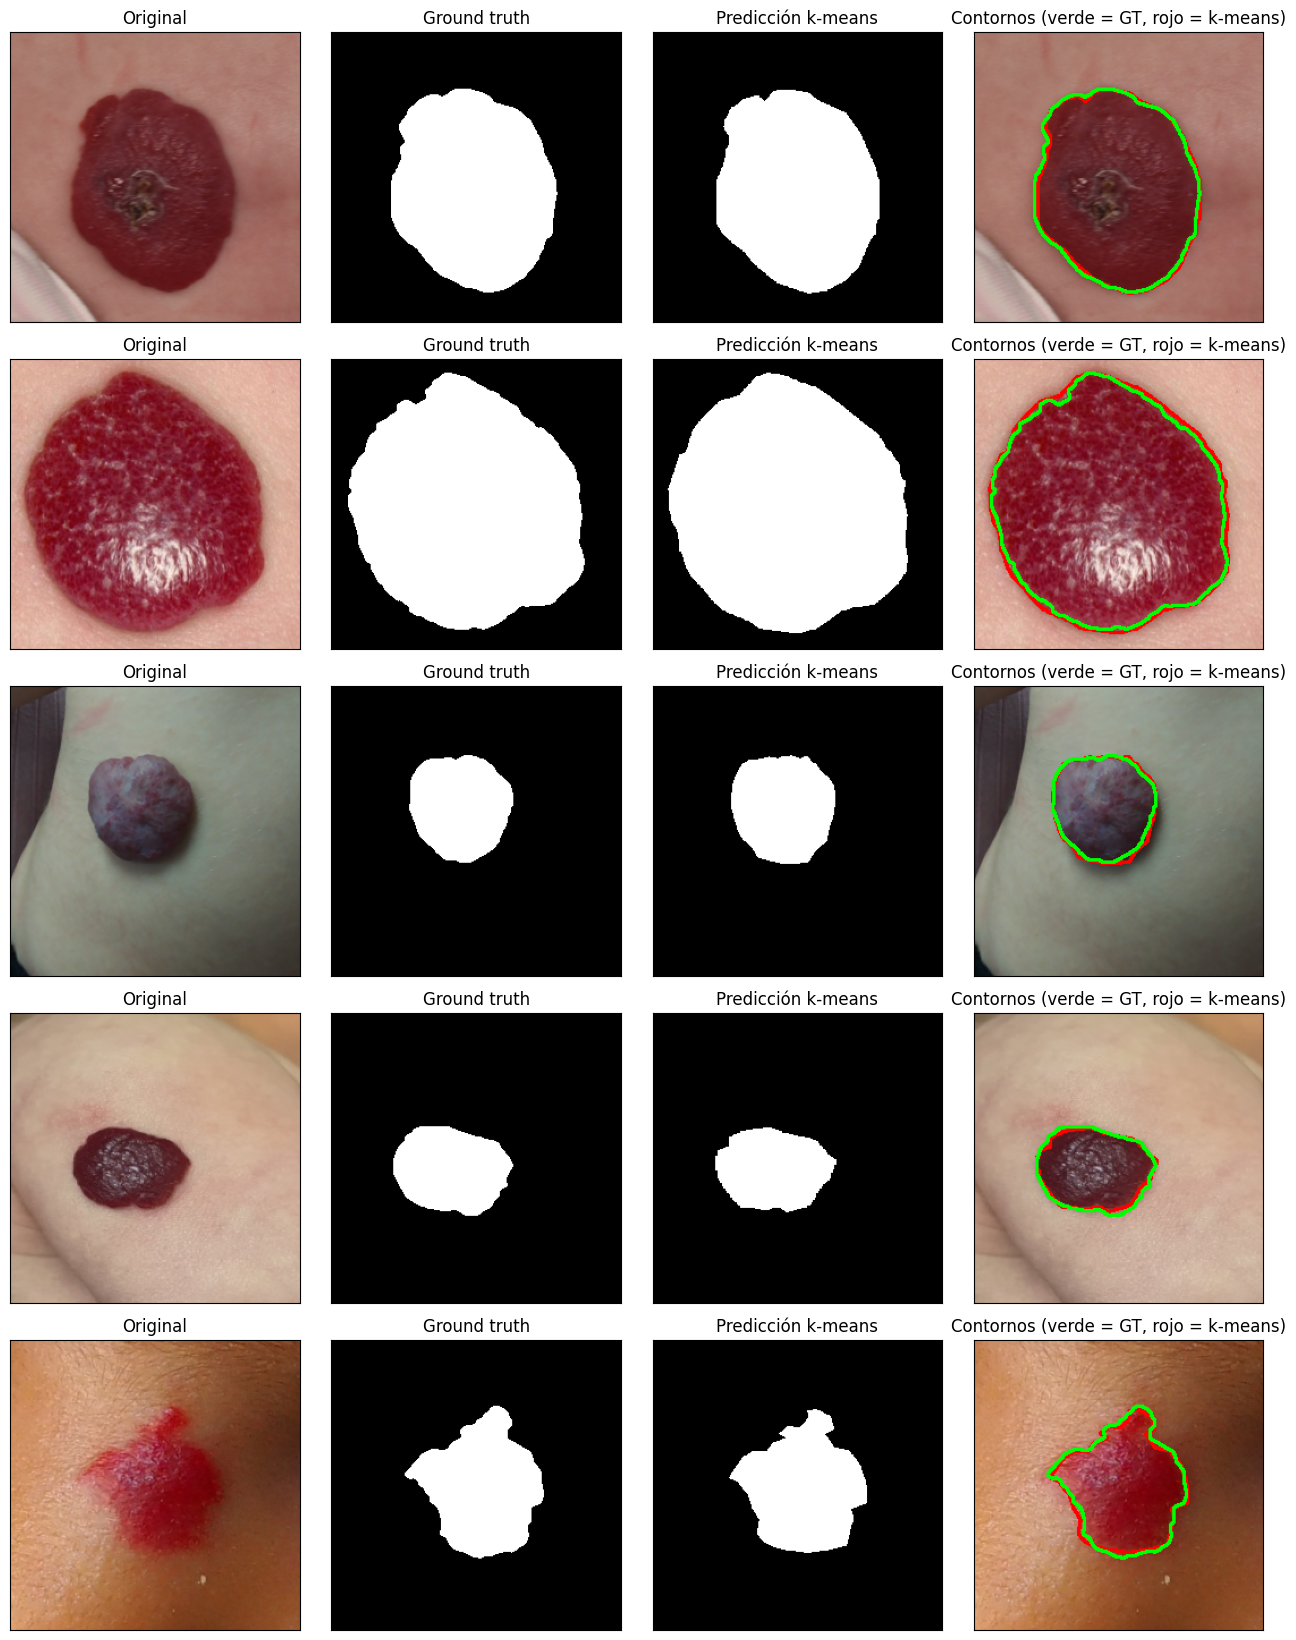

In [45]:
if GUARDAR:
    os.makedirs(CARPETA_SALIDA, exist_ok=True)

buenas = [i for i in range(N) if dice_oof[i] > UMBRAL_DICE]
buenas.sort(key=lambda i: -dice_oof[i])



mostrar = buenas if MAX_MOSTRAR is None else buenas[:MAX_MOSTRAR]
if MAX_MOSTRAR is not None and len(buenas) > MAX_MOSTRAR:


  if not buenas:
    print("\nNinguna imagen supera el umbral.")
  else:
    n = len(mostrar)
    fig, axes = plt.subplots(n, 4, figsize=(13, 3.3 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for fila, i in enumerate(mostrar):
        img, gt, seg = imagenes[i], mascaras[i], seg_oof[i]
        ax = axes[fila]
        ax[0].imshow(img);              ax[0].set_title("Original")
        ax[1].imshow(seg, cmap="gray"); ax[1].set_title("Ground truth")
        ax[2].imshow(gt,  cmap="gray"); ax[2].set_title("Predicción k-means")
        ax[3].imshow(dibujar_contornos(img, seg, gt))
        ax[3].set_title("Contornos (verde = GT, rojo = k-means)")

        for col in range(4):
            ax[col].set_xticks([]); ax[col].set_yticks([])

    plt.tight_layout()
    if GUARDAR:
        ruta_png = os.path.join(CARPETA_SALIDA, "resultados_kmeans_kfold_dice09.png")
        plt.savefig(ruta_png, dpi=200, bbox_inches="tight", facecolor="white")
        print(f"Figura guardada en {ruta_png}")
    plt.show()